In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(y_true, y_pred, title="Прогноз vs Истинные значения"):
    """
    Строит график сравнения истинных значений и прогноза
    """
    plt.figure(figsize=(12, 5))
    
    plt.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    plt.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [7]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:11:38,264] A new study created in memory with name: no-name-81b75333-4acd-485c-8bd5-5be1d01ae188
[I 2026-05-10 17:11:38,627] Trial 0 finished with value: 3.9254351066655224 and parameters: {'lags': 5, 'n_estimators': 693, 'learning_rate': 0.13445589499066452, 'max_depth': 10, 'subsample': 0.9554434921115196, 'colsample_bytree': 0.8391287036751731, 'colsample_bylevel': 0.5936696605813894, 'colsample_bynode': 0.9349691649515386, 'reg_alpha': 0.0008285363802494044, 'reg_lambda': 1.5246030539324202e-10, 'gamma': 0.01930008028124819, 'min_child_weight': 18, 'max_delta_step': 15}. Best is trial 0 with value: 3.9254351066655224.
[I 2026-05-10 17:11:38,840] Trial 1 finished with value: 3.1624676242752856 and parameters: {'lags': 4, 'n_estimators': 711, 'learning_rate': 0.03821082656213784, 'max_depth': 8, 'subsample': 0.6652811972794861, 'colsample_bytree': 0.8935191565420073, 'colsample_bylevel': 0.8141409831151203, 'colsample_bynode': 0.4221834220730537, 'reg_alpha': 2.50842

Лучшие параметры = {'lags': 4, 'n_estimators': 465, 'learning_rate': 0.04914082149441698, 'max_depth': 1, 'subsample': 0.4091796245839978, 'colsample_bytree': 0.7754066071190072, 'colsample_bylevel': 0.706701074349265, 'colsample_bynode': 0.6247247215631226, 'reg_alpha': 0.0006265948895893143, 'reg_lambda': 5.760225943683228, 'gamma': 0.0348711595832624, 'min_child_weight': 6, 'max_delta_step': 12}
Лучший RMSE score = 2.3800101435951495


Глубина 5

In [11]:
depth = 5
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [12]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:15:20,252] A new study created in memory with name: no-name-10088279-e27d-4740-ae41-bcad539755b6
[I 2026-05-10 17:15:21,171] Trial 0 finished with value: 1.4966820923923914 and parameters: {'lags': 2, 'n_estimators': 1367, 'learning_rate': 0.0007337722848854878, 'max_depth': 14, 'subsample': 0.9270013104485442, 'colsample_bytree': 0.871244493875808, 'colsample_bylevel': 0.8218677998807117, 'colsample_bynode': 0.663171292172509, 'reg_alpha': 0.00044842539900746115, 'reg_lambda': 0.001390352655483541, 'gamma': 3.3706117145775825e-08, 'min_child_weight': 16, 'max_delta_step': 14}. Best is trial 0 with value: 1.4966820923923914.
[I 2026-05-10 17:15:21,429] Trial 1 finished with value: 1.2088869771798123 and parameters: {'lags': 5, 'n_estimators': 330, 'learning_rate': 0.6746355079893629, 'max_depth': 7, 'subsample': 0.7359534118554896, 'colsample_bytree': 0.4911984488473865, 'colsample_bylevel': 0.4057067278396762, 'colsample_bynode': 0.7597572641601607, 'reg_alpha': 3.015

Лучшие параметры = {'lags': 2, 'n_estimators': 777, 'learning_rate': 0.3383227612641458, 'max_depth': 3, 'subsample': 0.6910500554106171, 'colsample_bytree': 0.9102380976592765, 'colsample_bylevel': 0.5114704636416396, 'colsample_bynode': 0.7573000923107179, 'reg_alpha': 0.07678233293743592, 'reg_lambda': 1.040915439016307e-06, 'gamma': 2.880734453499902e-07, 'min_child_weight': 24, 'max_delta_step': 7}
Лучший RMSE score = 0.414401850556434


Глубина 10

In [15]:
depth = 10
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [16]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:19:58,686] A new study created in memory with name: no-name-948345c5-5554-4158-acb5-27a4adf037a8
[I 2026-05-10 17:19:59,005] Trial 0 finished with value: 0.894397354008121 and parameters: {'lags': 3, 'n_estimators': 756, 'learning_rate': 0.0005526830223407694, 'max_depth': 11, 'subsample': 0.7504437028962065, 'colsample_bytree': 0.5888965253458525, 'colsample_bylevel': 0.49963400631398414, 'colsample_bynode': 0.4262790924606559, 'reg_alpha': 1.334211166988001e-10, 'reg_lambda': 2.2632169085806672e-08, 'gamma': 0.7145222994351407, 'min_child_weight': 24, 'max_delta_step': 18}. Best is trial 0 with value: 0.894397354008121.
[I 2026-05-10 17:19:59,135] Trial 1 finished with value: 0.39583679536845645 and parameters: {'lags': 4, 'n_estimators': 272, 'learning_rate': 0.2185689818756893, 'max_depth': 4, 'subsample': 0.8508234516939049, 'colsample_bytree': 0.9640019902069245, 'colsample_bylevel': 0.5653731882049373, 'colsample_bynode': 0.9668144024491695, 'reg_alpha': 4.06055

Лучшие параметры = {'lags': 5, 'n_estimators': 906, 'learning_rate': 0.02890379681191596, 'max_depth': 5, 'subsample': 0.47063004322917595, 'colsample_bytree': 0.7641119369098918, 'colsample_bylevel': 0.8265648291373716, 'colsample_bynode': 0.6407913990489128, 'reg_alpha': 5.94480030625621e-07, 'reg_lambda': 2.1786051909732175e-07, 'gamma': 6.743846701536673e-07, 'min_child_weight': 28, 'max_delta_step': 7}
Лучший RMSE score = 0.2808152694153388


In [17]:
best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
best_model.fit(
            y=df_train[target_col],
            exog=df_train[exog_cols],
        )

joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_10']

RMSE на тесте = 0.49585770130281087


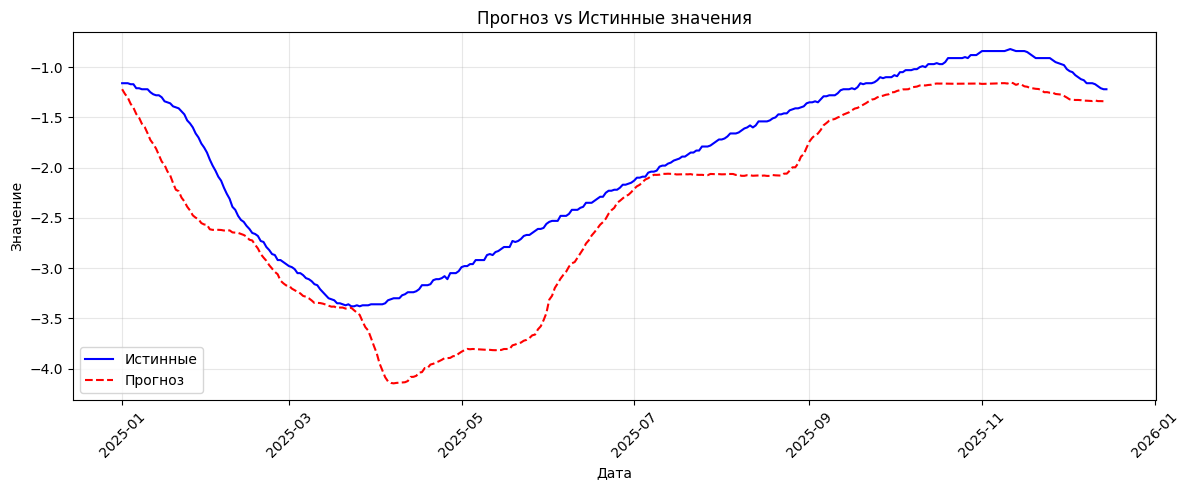

In [18]:
model = joblib.load(model_path)
last_window = df_train_full[target_col].iloc[-len(model.lags):]
y_pred = model.predict(
            steps=len(df_test),
            exog=df_test[exog_cols],
            last_window = last_window
        )

rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
print(f'RMSE на тесте = {rmse}')

plot_forecast(df_test[target_col], y_pred)

In [19]:
importances = model.get_feature_importances()
importances

,feature,importance
2,lag_3,0.210699
0,lag_1,0.167905
5,Месяц_sin,0.167519
1,lag_2,0.167307
4,lag_5,0.110750
3,lag_4,0.108596
7,day_of_year_sin,0.037274
8,day_of_year_cos,0.019025
6,Месяц_cos,0.010925
